# Imports

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import qiskit
import numpy as np
from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram
from qiskit.circuit import Parameter
import random

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from qiskit.circuit import Parameter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading data


In [2]:
iris = load_iris()
X, y = iris.data, iris.target

## Data exploration

In [3]:
# Data exploration
print(f"Number of data points (rows): {X.shape[0]}")
print(f"Number of input dimensions (features): {X.shape[1]}")
print(f"Number of targets: {len(y)}")
print(f"Range of feature values: min {np.min(X)} - max {np.max(X)}")
print(f"Unique target values: {np.unique(y)}")

Number of data points (rows): 150
Number of input dimensions (features): 4
Number of targets: 150
Range of feature values: min 0.1 - max 7.9
Unique target values: [0 1 2]


## Normalizing and scaling data

In [4]:
# Normalize each column independently to the range 0 to π
min_vals = np.min(X, axis=0)  # Min values for each column
max_vals = np.max(X, axis=0)  # Max values for each column

normalized_X = (X - min_vals) / (max_vals - min_vals) * np.pi

in_min, in_max = normalized_X.min(),normalized_X.max()

print(f"Input range: ({in_min}-{in_max})")

Input range: (0.0-3.141592653589793)


## Splitting data

In [5]:
random_seed = 42
np.random.seed(random_seed)
X_train, X_val_test, y_train, y_val_test = train_test_split(normalized_X, y, test_size=0.30, random_state=random_seed)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.50, random_state=random_seed)

## Building circuits

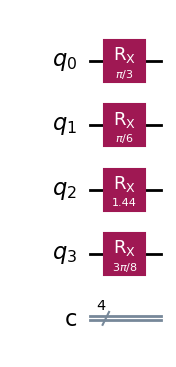

In [6]:
def create_encoding_circuit(features, n_qubits=4):
    n_features = len(features)
    qc = QuantumCircuit(n_qubits, n_features)
    for i in range(n_features):
        qc.rx(features[i],i)
    return qc

encode_circuit = create_encoding_circuit(X_train[0], n_qubits=4)

encode_circuit.draw("mpl")

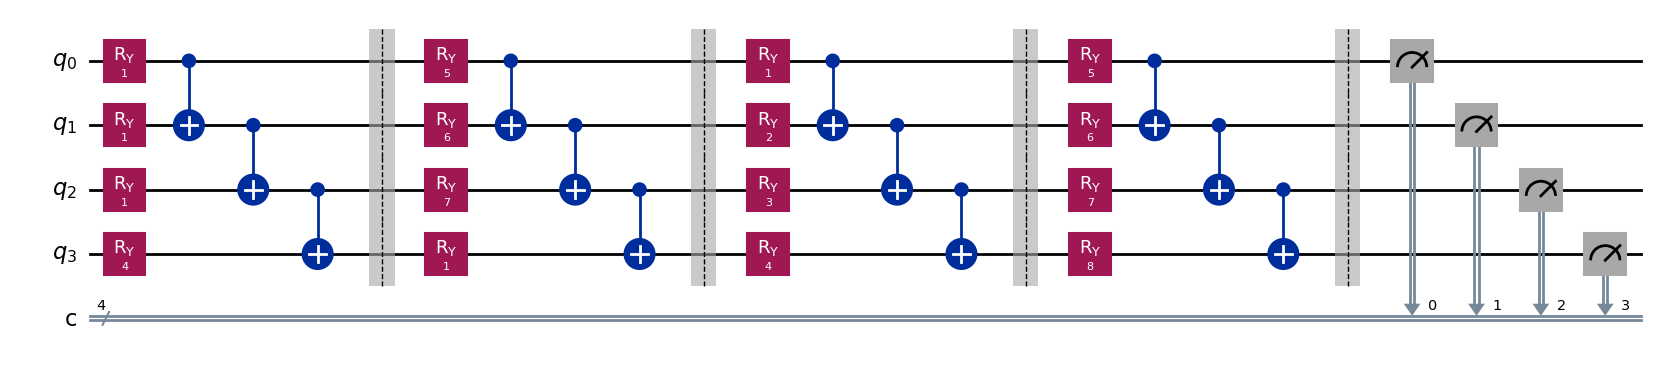

In [7]:


class QuantumNN:
    def __init__(self, n_layers, n_qubits):
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.params = [Parameter(f"θ_{i}_{j}") for i in range(n_layers) for j in range(n_qubits)]
        self.qc = self.create_simple_variational_circuit(n_layers, n_qubits)
        self.values = [np.random.uniform(0, np.pi) for _ in self.params]
        self.best_values = self.values
        

    def get_parameters(self):
        return self.param_values

    def get_values(self):
        return self.values

    def update_values(self, values):
        self.values = values
    
    def get_qc(self, values=None):
        if values==None:
            param_values = {param: value for param, value in zip(self.params, self.values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        else:
            param_values = {param: value for param, value in zip(self.params, values)}
            new_qc = self.qc.assign_parameters(param_values, inplace=False)
        return new_qc

    
    def create_simple_variational_circuit(self, n_layers, n_features):    
        qc = QuantumCircuit(self.n_qubits, self.n_qubits)
        for i in range(self.n_layers):
            for j in range(self.n_qubits):
                qc.ry(self.params[i * self.n_qubits + j], j)
            for j in range(self.n_qubits - 1):
                qc.cx(j, j + 1)
            qc.barrier()
    
        qc.measure(range(self.n_qubits), range(self.n_qubits))
        return qc

qnn = QuantumNN(4, 4)
qnn.get_qc(values=[1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]).draw(output="mpl")
qnn.get_qc(values=[1, 1, 1, 4, 5, 6, 7, 1, 1, 2, 3, 4, 5, 6, 7, 8]).draw(output="mpl")

In [8]:
def run_qc(qc, shots=1000, label_mapping = {
        '0000': '0', '0001': '1', '0010': '2', '0011': '0',
        '0100': '1', '0101': '2', '0110': '0', '0111': '1',
        '1000': '2', '1001': '0', '1010': '1', '1011': '2',
        '1100': '0', '1101': '1', '1110': '2', '1111': '0'
    },seed=random_seed):
    simulator = AerSimulator()
    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots,seed_simulator=seed).result()
    counts = result.get_counts()
    
    label_counts = {'0': 0, '1': 0, '2': 0}
    for outcome, count in counts.items():
        label = label_mapping[outcome]
        label_counts[label] += count
    total_counts = sum(label_counts.values())
    label_probabilities = {label: count / total_counts for label, count in label_counts.items()}
    return label_probabilities

In [9]:
def calculate_loss(predicted_probs, actual):
    n = len(predicted_probs)
    actual_list = [1 if i == actual else 0 for i in range(n)]    
    predicted_probs_list = []
    for i in range(n):
        predicted_probs_list.append(predicted_probs[str(i)])
    loss = log_loss([actual_list], [predicted_probs_list])
    return loss


def calc_gradient(neg_loss, pos_loss, epsilon):
    gradient = (pos_loss - neg_loss) / (2 * epsilon)
    return gradient


def evaluate_shifted_loss(enc_qc, qnn, parameters, shift, index, actual):
    shifted_parameters = parameters[:]
    shifted_parameters[index] += shift
    
    shifted_qc = qnn.get_qc(values=shifted_parameters)
    shifted_qc = enc_qc.compose(shifted_qc)
    
    shifted_probs = run_qc(shifted_qc)
    shifted_loss = calculate_loss(shifted_probs, actual)

    return shifted_loss

def gradient_descent(enc_qc, qnn, actual, epsilon=0.1, lr=0.1):
    gradients = []
    original_parameters = qnn.get_values()
    
    for i in range(len(original_parameters)):
        lower_loss = evaluate_shifted_loss(enc_qc, qnn, original_parameters, -epsilon, i, actual)
        upper_loss = evaluate_shifted_loss(enc_qc, qnn, original_parameters, epsilon, i, actual)
        
        gradient = calc_gradient(lower_loss, upper_loss, epsilon)
        gradients.append(gradient)

    new_values = original_parameters - (lr * gradients)
    qc.update_values(new_values)

    return new_values



In [10]:
def calc_accuracy_loss(qnn, X, y):
    correct_predictions = 0
    loss = 0
    n = len(X)
    for i in range(n):
        features = X[i]
        actual = y[i]
        enc_qc = create_encoding_circuit(features, n_qubits=qnn.n_qubits)

        qc = enc_qc.composed(qnn.get_qc)
        probs = run_qc(qc)

        # Calculate validation loss for the current sample
        loss += calculate_loss(probs, actual)

        # Determine the predicted label for accuracy calculation
        predicted = max(probs, key=probs.get)
        if int(predicted) == actual:
            correct_predictions += 1

    loss = loss / len(X_val)
    accuracy = correct_predictions / len(X_val)
    return accuracy, loss
    

In [11]:
def plot_learning_curves(training_losses, validation_losses, epochs):
    """Plot the training and validation learning curves."""
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), training_losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), validation_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


def train(qnn, X_train, y_train, X_val, y_val, lr=1, epsilon=0.1, epochs=1, batch_size=8):
    training_losses = []
    validation_losses = []
    
    best_parameters = []
    best_validation_loss = float('inf')
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1 } of {epochs}")
        batch_indices = np.random.choice(len(X_train), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]

        for i in range(len(X_batch)):
            features = X_batch[i]
            actual = y_batch[y]
            enc_qc = create_encoding_circuit(features, n_qubits=qnn.n_qubits)

            parameters = gradient_descent(enc_qc, qnn, actual, epsilon=epsilon, lr=lr)
    




        

In [12]:
qnn = QuantumNN(4, 4)
train(qnn, X_train, y_train, X_val, y_val, lr=1, epsilon=0.1, epochs=1, batch_size=8)

Epoch 1 of 1


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()